# CMA-ES run analysis

In [1]:
from pathlib import Path

import pandas as pd
import yaml
import matplotlib.pyplot as plt

NBEM = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "processed_data").exists())
RESULTS = NBEM / "CMAES-results"
DEFAULTS = {k: v for s in yaml.safe_load(open(NBEM / "processed_data/bem/params.yaml")).values() for k, v in s.items()}
pd.set_option("display.max_columns", None, "display.width", None)


def flatten_yaml(path):
    return {k: v for s in yaml.safe_load(open(path)).values() for k, v in s.items()}


def load_run(d):
    lines = [l.strip() for l in open(d / "coeff.txt") if l.strip()]
    return dict(
        coeffs=flatten_yaml(d / "best.yaml"),
        objective=lines[1],            # force-only / force+torque
        freed=lines[2:],               # params the fit actually moved
        metrics=pd.read_csv(d / "metrics.csv").iloc[0],
    )


RUNS = {
    d.name: load_run(d)
    for d in sorted(RESULTS.iterdir())
    if d.is_dir() and (d / "coeff.txt").exists() and (d / "metrics.csv").exists()
}
list(RUNS)

['2026-07-14-00-00-00',
 '2026-07-15-00-00-00',
 '2026-07-21-14-54-19',
 '2026-07-21-22-56-43',
 '2026-07-22-10-20-11',
 '2026-07-22-11-18-46',
 '2026-07-22-12-36-31',
 '2026-07-22-14-18-47',
 '2026-07-22-15-14-56',
 '2026-07-22-18-39-25',
 '2026-07-23-11-39-35',
 '2026-07-23-11-57-11']

## Coefficients

- **`agi`** — coeffs from the Agilicious port (`agi_coeffs.yaml`); `thrust_scale` = `NaN` (lives in a quad YAML not in the extracted sources).
- **`2026-07-14-00-00-00`** — freed nothing → canonical `REGISTRY` defaults (`processed_data/bem/params.yaml`); **the baseline row.**
- **`<ts>`** — each run's `best.yaml`.
- `objective` (from `coeff.txt`): `force-only` / `force+torque`.
- `freed` — params the fit could move (shaded gray); all else stays at default.

**IMPORTANT**

From `2026-07-22-12-36-31` onward, new loss function - normalized by baseline MSE, instead of magnitude. 

In [2]:
AGI = flatten_yaml(Path.cwd() / "CMAES-results-analysis/agi_coeffs.yaml") \
    if (Path.cwd() / "CMAES-results-analysis").exists() else flatten_yaml(Path.cwd() / "agi_coeffs.yaml")

rows = {"agi": {"objective": "—", **AGI}}
for ts, r in RUNS.items():
    rows[ts] = {"objective": r["objective"], **r["coeffs"]}

coeff_df = pd.DataFrame(rows).T[["objective", *DEFAULTS]]
for c in DEFAULTS:
    coeff_df[c] = coeff_df[c].astype(float)

LOSS_CHANGE = "2026-07-22-12-36-31"  # first run with the normalized loss


def hl_loss_change(row):
    b = "border-top: 3px solid #d55e00" if row.name == LOSS_CHANGE else ""
    return [b] * len(row)


def hl_freed(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for ts, r in RUNS.items():
        for p in r["freed"]:
            if p in styles.columns:
                styles.loc[ts, p] = "background-color: #d9d9d9; color: black"
    return styles


OUTLINE_COLS = ["lift_offset", "hforce_scale", "thrust_scale"]
header_styles = {c: [{"selector": "th", "props": "outline: 2px solid #2e7d32; outline-offset: -2px;"}]
                 for c in OUTLINE_COLS}

coeff_df.style \
    .apply(hl_freed, axis=None) \
    .apply(hl_loss_change, axis=1) \
    .set_table_styles(header_styles, axis=0, overwrite=False) \
    .format({c: "{:g}" for c in DEFAULTS})

,objective,lift_coefficient,drag_coefficient,hinge_spring_constant,lift_offset,hforce_scale,pitch,twist,chord_inner,chord_outer,radius,num_blades,air_density,thrust_scale,dx,dy,dz,horizontal_drag_coefficient,vertical_drag_coefficient,frontarea_x,frontarea_y,frontarea_z
agi,—,4.79707,4.16886,5.89,0.07,3,22.95,-8,0.017,0.008,0.06477,3,1.204,nan,0.078,0.1,0.027,1,1,0.015,0.015,0.03
2026-07-14-00-00-00,—,15.2421,13.5489,5.89,0,1,21.77,-11,0.017,0.007,0.06477,3,1.204,1,0.078,0.1,0.027,1,1,0.0054,0.009,0.006
2026-07-15-00-00-00,force-only,14.329,14.454,5.89,0,1,21.77,-11,0.017,0.007,0.06477,3,1.204,1,0.078,0.1,0.027,1,1,0.0054,0.009,0.006
2026-07-21-14-54-19,force-only,4.84635,3.08587,1.72903,0.0455777,2.65155,27.0201,-11,0.017,0.007,0.06477,3,1.204,1,0.078,0.1,0.027,1,1,0.0054,0.009,0.006
2026-07-21-22-56-43,force+torque,0.884087,0.5,0.50423,0.221234,1.2742,10.9628,-11,0.017,0.007,0.06477,3,1.204,1,0.078,0.1,0.027,1,1,0.0054,0.009,0.006
2026-07-22-10-20-11,force+torque,15.2421,23.902,1.68921,0,1,21.77,-11,0.017,0.007,0.06477,3,1.204,1,0.04,0.0506225,-0.049959,1,1,0.0054,0.009,0.006
2026-07-22-11-18-46,force+torque,15.2421,0.500003,0.5,0,1,21.77,-11,0.017,0.007,0.06477,3,1.204,1,0.078,0.1,0.027,1,1,0.0054,0.009,0.006
2026-07-22-12-36-31,force+torque,15.2421,22.1552,6.23635,0,1,21.77,-11,0.017,0.007,0.06477,3,1.204,1,0.0400042,0.0504474,-0.05,1,1,0.0054,0.009,0.006
2026-07-22-14-18-47,force-only,14.2712,13.5489,5.89,0,1,21.77,-11,0.017,0.007,0.06477,3,1.204,1,0.078,0.1,0.027,1,1,0.0054,0.009,0.006
2026-07-22-15-14-56,force+torque,14.5674,16.9125,2.35041,0,1,21.77,-11,0.017,0.007,0.06477,3,1.204,1,0.04,0.0500665,-0.0499632,1,1,0.0054,0.009,0.006


## Fit metrics

BEM+nn, BEM paper baselines are on test set. Rest of the runs (even paper BEM) on the training set (20k sample). Green is best value, red worst.

In [3]:
BASELINE = pd.DataFrame({
    # paper Table II (unseen test set):
    "paper BEM":    {"Fxy": 0.803, "Fz": 1.265, "F": 0.982, "Mxy": 0.090, "Mz": 0.017, "M": 0.074},
    # "paper BEM+NN": {"Fxy": 0.204, "Fz": 0.504, "F": 0.335, "Mxy": 0.014, "Mz": 0.004, "M": 0.012},
}).T

metrics_df = pd.DataFrame({ts: r["metrics"] for ts, r in RUNS.items()}).T
metrics_df = pd.concat([BASELINE, metrics_df])[["Fxy", "Fz", "F", "Mxy", "Mz", "M"]]
metrics_df.index.name = "run"

BASE = "2026-07-14-00-00-00"  # freed nothing -> the baseline run
metrics_df["F impr%"] = (metrics_df.loc[BASE, "F"] - metrics_df["F"]) / metrics_df.loc[BASE, "F"] * 100
metrics_df["M impr%"] = (metrics_df.loc[BASE, "M"] - metrics_df["M"]) / metrics_df.loc[BASE, "M"] * 100
metrics_df = metrics_df[["Fxy", "Fz", "F", "F impr%", "Mxy", "Mz", "M", "M impr%"]]

GREEN = "#2e7d32"


def hl_best_worst(col):
    s = pd.Series("", index=col.index)
    s[col.idxmin()] = "background-color: #2e7d32; color: white"
    s[col.idxmax()] = "background-color: #c62828; color: white"
    return s


def color_impr(col):
    return ["color: #2e7d32" if v > 0 else "color: #c62828" if v < 0 else "" for v in col]


def box_fm(df):  # left/right on every cell + bottom on last row -> one box per column
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for c in ["F", "M"]:
        styles[c] = f"border-left: 2px solid {GREEN}; border-right: 2px solid {GREEN};"
        styles.loc[df.index[-1], c] += f" border-bottom: 2px solid {GREEN};"
    return styles


table_styles = [{"selector": "", "props": "border-collapse: collapse;"}]
for c in ["F", "M"]:  # close the top of the box on the header
    table_styles.append({"selector": f"th.col_heading.level0.col{metrics_df.columns.get_loc(c)}",
                         "props": f"border-top: 2px solid {GREEN}; border-left: 2px solid {GREEN}; border-right: 2px solid {GREEN};"})

metrics_df.style \
    .apply(hl_best_worst, subset=["F", "M"]) \
    .apply(color_impr, subset=["F impr%", "M impr%"]) \
    .apply(hl_loss_change, axis=1) \
    .apply(box_fm, axis=None) \
    .set_table_styles(table_styles, overwrite=False) \
    .format({"Fxy": "{:.4f}", "Fz": "{:.4f}", "F": "{:.4f}", "Mxy": "{:.4f}",
             "Mz": "{:.4f}", "M": "{:.4f}", "F impr%": "{:+.1f}%", "M impr%": "{:+.1f}%"})

,Fxy,Fz,F,F impr%,Mxy,Mz,M,M impr%
run,,,,,,,,
paper BEM,0.8030,1.2650,0.9820,-2.8%,0.0900,0.0170,0.0740,+10.6%
2026-07-14-00-00-00,0.4831,1.5073,0.9555,+0.0%,0.1010,0.0119,0.0827,+0.0%
2026-07-15-00-00-00,0.4846,1.4493,0.9256,+3.1%,0.0983,0.0120,0.0806,+2.6%
2026-07-21-14-54-19,0.3694,0.8527,0.5774,+39.6%,0.1020,0.0114,0.0835,-0.9%
2026-07-21-22-56-43,0.8988,10.7939,6.2749,-556.7%,0.0274,0.0076,0.0228,+72.4%
2026-07-22-10-20-11,0.4152,1.5001,0.9301,+2.7%,0.0227,0.0149,0.0204,+75.3%
2026-07-22-11-18-46,0.6218,1.5903,1.0492,-9.8%,0.0970,0.0088,0.0793,+4.1%
2026-07-22-12-36-31,0.4245,1.4926,0.9288,+2.8%,0.0233,0.0143,0.0207,+74.9%
2026-07-22-14-18-47,0.4940,1.4432,0.9257,+3.1%,0.0979,0.0118,0.0802,+3.0%


## Convergence

Loss trace (`convergence.csv`) per run.

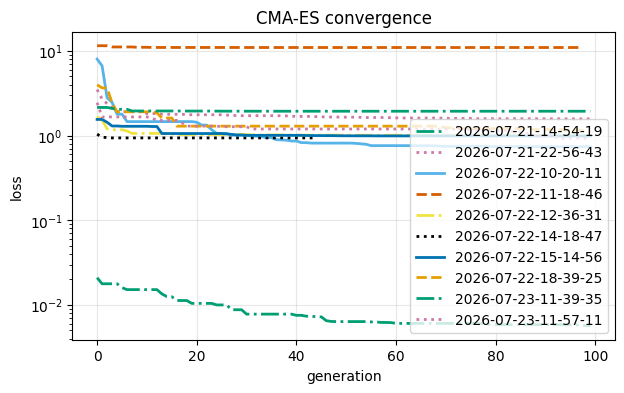

In [4]:
# Okabe-Ito colorblind-safe palette + varied linestyles
CB = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442", "#000000"]
STYLES = ["-", "--", "-.", ":"]

fig, ax = plt.subplots(figsize=(7, 4))
for i, ts in enumerate(RUNS):
    path = RESULTS / ts / "convergence.csv"
    if path.stat().st_size == 0:
        continue
    conv = pd.read_csv(path)
    ax.plot(conv["gen"], conv["loss"], label=ts,
            color=CB[i % len(CB)], linestyle=STYLES[i % len(STYLES)], lw=2)
ax.set(xlabel="generation", ylabel="loss", yscale="log", title="CMA-ES convergence")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()